In [1]:
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq_nex, AmpInterpKerrEccEq
import numpy as np
import matplotlib.pyplot as plt
from few.utils.mappings.kerrecceq import kerrecceq_backward_map, kerrecceq_backward_map_nex, z_of_a, y_of_x, z_of_a_nex, DELTAPMIN_REGIONC
from few.utils.geodesic import get_separatrix

kerr_amp_spline_nex = AmpInterpKerrEccEq_nex()
kerr_amp_spline = AmpInterpKerrEccEq()

In [78]:
a = 0.99
p = 3.0
e = 0.1
xI = 1.0
specific_modes = [(2,2,0,0)]
specific_amplitudes = kerr_amp_spline(a, p, e, xI, specific_modes=specific_modes)
specific_amplitudes_nex = kerr_amp_spline_nex(a, p, e, xI, specific_modes=specific_modes)
specific_amplitudes_nex, specific_amplitudes



({(2, 2, 0, 0): array([1.24248651+0.2036261j])},
 {(2, 2, 0, 0): array([1.21249589-0.03951598j])})

In [119]:

# A rectilinear grid
uv = np.linspace(1e-5, 1 - 1e-5, 101)
wv = np.linspace(1e-5, 1 - 1e-5, 101)

a = 0.99
z = z_of_a(a)
z_nex = z_of_a_nex(a)
y = y_of_x(1)

# For a given rectilinear grid, compute the associated (a,p,e,x) grid
u_grid, w_grid = np.asarray(np.meshgrid(uv, wv, indexing="ij")).reshape(2, -1)

a_grid, p_grid, e_grid, xI_grid = kerrecceq_backward_map(
    u_grid, w_grid, np.ones_like(u_grid) * y, np.ones_like(u_grid) * z, kind="amplitude"
)

a_grid_nex, p_grid_nex, e_grid_nex, xI_grid_nex = kerrecceq_backward_map_nex(
    u_grid, w_grid, np.ones_like(u_grid) * y, np.ones_like(u_grid) * z_nex, kind="amplitude"
)

print("Total trajectory points:", w_grid.shape[0])

Total trajectory points: 10201


In [120]:
teuk_all_amps = kerr_amp_spline(a, p_grid, e_grid, xI_grid).reshape(
    uv.size, wv.size, -1
)

teuk_all_amps_nex = kerr_amp_spline_nex(a, p_grid_nex, e_grid_nex, xI_grid_nex).reshape(
    uv.size, wv.size, -1
)

# Specific mode amplitudes for the given (a,p,e,x) data points.
specific_modes = [(2, 2, 0, 0)]

teuk_specific_amps = kerr_amp_spline(a, p_grid, e_grid, xI_grid, specific_modes=specific_modes)
teuk_specific_amps_nex = kerr_amp_spline_nex(a, p_grid_nex, e_grid_nex, xI_grid_nex, specific_modes=specific_modes)

# We can find the index to these modes to check
inds = np.array([kerr_amp_spline.special_index_map[lmn] for lmn in specific_modes])
print("Indices of interest:", inds)

# Making sure they are the same
print(
    np.allclose(
        teuk_specific_amps[(2, 2, 0, 0)].reshape(uv.size, wv.size),
        teuk_all_amps[:, :, inds[0]],
    )
)

Indices of interest: [1165]
True


In [70]:
rel_diff

array([[ 0.        ,  0.4641957 ,  0.52868619, ...,  1.10201297,
         0.86838319,  0.68686053],
       [ 0.        ,  0.49401983,  0.55192787, ...,  1.09071193,
         0.87041184,  0.69905137],
       [ 0.        ,  0.51825892,  0.56893022, ...,  1.14638536,
         0.91679628,  0.73961608],
       ...,
       [ 0.        ,  0.        ,  0.81258466, ..., 29.90197889,
        33.06220135, 37.46441835],
       [ 0.        ,  0.        ,  0.82408069, ..., 32.49197471,
        36.69621617, 42.53001831],
       [ 0.        ,  0.        ,  0.83494941, ..., 35.7700719 ,
        41.34364506, 49.12630409]], shape=(101, 101))

In [108]:
p_grid.size

10201

Text(0.5, 0.98, 'Contour plots of |$A_{(10, 9, 0, 0)}$| for a=0.999')

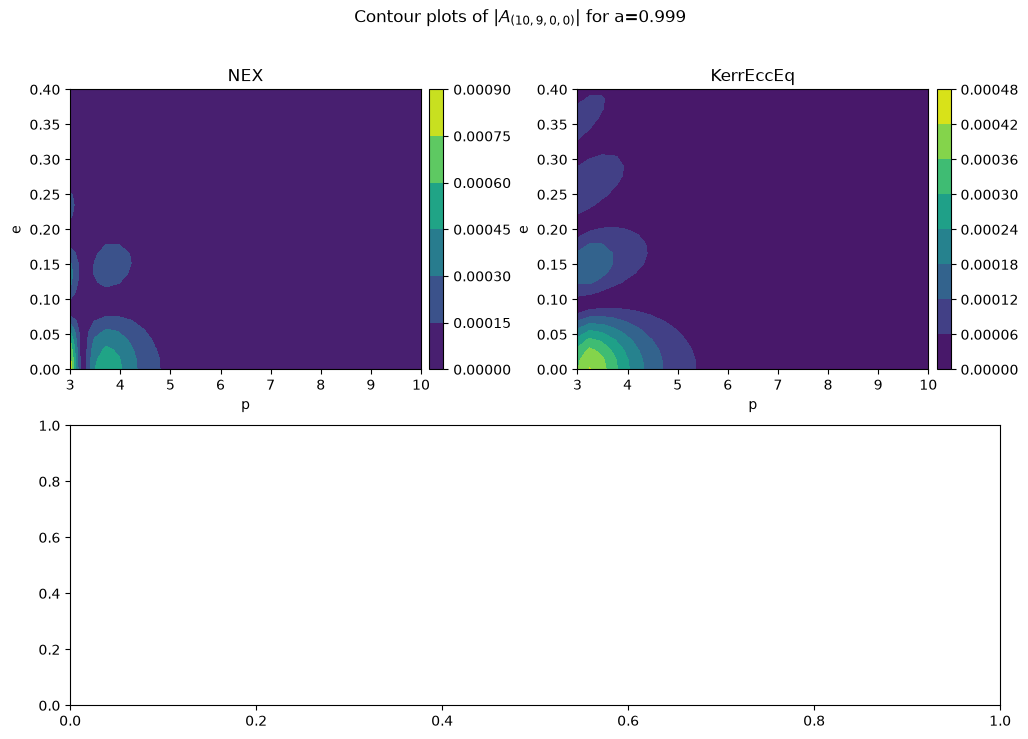

In [22]:
mode = (10, 9, 0, 0)

a=0.999
n1=30
p = np.linspace(3, 10, n1)
e = np.linspace(0, 0.4, n1)

p_grid, e_grid = np.asarray(np.meshgrid(p, e, indexing="ij")).reshape(2, -1)
xI_grid = np.ones_like(p_grid) 

teuk_all_amps = kerr_amp_spline(a, p_grid, e_grid, xI_grid).reshape(
    n1, n1, -1
)

teuk_all_amps_nex = kerr_amp_spline_nex(a, p_grid, e_grid, xI_grid).reshape(
    n1, n1, -1
)


Nex_Z = np.imag(teuk_all_amps_nex[:, :, kerr_amp_spline_nex.special_index_map[mode]])
Few_Z = np.imag(teuk_all_amps[:, :, kerr_amp_spline.special_index_map[mode]])


fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 2])


axs = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, :])  #Top left, top right, bottom


cf0 = axs[0].contourf(
    p_grid.reshape(n1, n1),
    e_grid.reshape(n1, n1),
    np.abs(Nex_Z),
)
cb0 = fig.colorbar(cf0, ax=axs[0],pad = 0.02)

axs[0].set_title("NEX")
axs[0].set_xlabel("p")
axs[0].set_ylabel("e")


cf1 = axs[1].contourf(
    p_grid.reshape(n1, n1),
    e_grid.reshape(n1, n1),
    np.abs(Few_Z),
)
cb1 = fig.colorbar(cf1, ax=axs[1],pad = 0.02)
axs[1].set_title("KerrEccEq")
axs[1].set_xlabel("p")
axs[1].set_ylabel("e")
axs[1].set_ylim(0, 0.4)

''''

rel_diff = np.abs(
    (np.abs(Nex_Z - Few_Z)) / np.abs(Few_Z))

rel_diff = np.where(np.abs(Few_Z) < 1e-3, 1, rel_diff)

cf2 = axs[2].contourf(
    p_grid.reshape(n1, n1),
    e_grid.reshape(n1, n1),
    rel_diff,levels =200
)
cb2 = fig.colorbar(cf2, ax=axs[2],pad = 0.02)
axs[2].set_title("Relative Difference")
axs[2].set_xlabel("p")
axs[2].set_ylabel("e")

axs[0].set_title("NEX")
axs[0].set_xlabel("p")
axs[0].set_ylabel("e")
'''

plt.suptitle(fr"Contour plots of |$A_{{{mode}}}$| for a={a}")



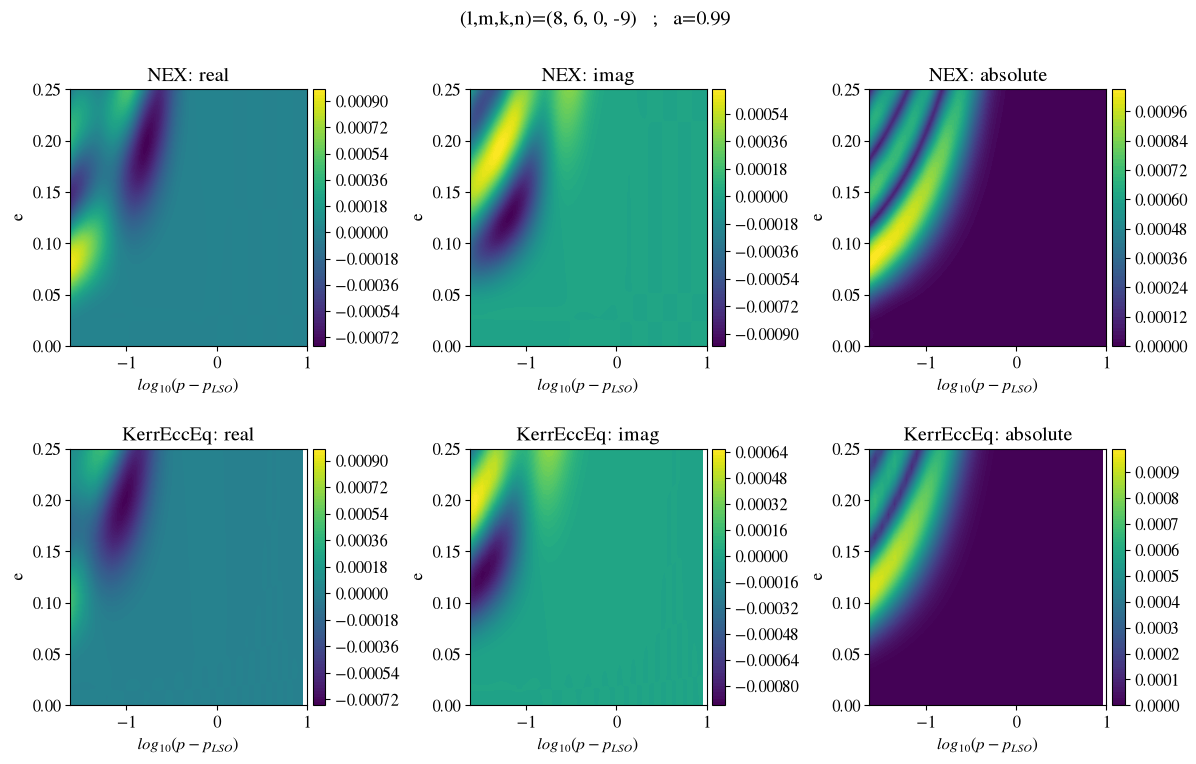

In [96]:
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 12,
})
l,m,n =8,6,-9
mode = (l,m,0,n)

a=0.999
n1=100
lvls = 100

funcs = [np.real, np.imag, np.abs]

uv = np.linspace(1e-5, 1 - 1e-5, n1)
wv = np.linspace(1e-5, 1 - 1e-5, n1)

a = 0.99
z = z_of_a(a)
z_nex = z_of_a_nex(a)
y = y_of_x(1)

u_grid, w_grid = np.asarray(np.meshgrid(uv, wv, indexing="ij")).reshape(2, -1)

a_grid, p_grid, e_grid, xI_grid = kerrecceq_backward_map(
    u_grid, w_grid, np.ones_like(u_grid) * y, np.ones_like(u_grid) * z, kind="amplitude"
)
plso = get_separatrix(a_grid,e_grid, xI_grid) 

a_grid_nex, p_grid_nex, e_grid_nex, xI_grid_nex = kerrecceq_backward_map_nex(
    u_grid, w_grid, np.ones_like(u_grid) * y, np.ones_like(u_grid) * z_nex, kind="amplitude"
)
plso_nex = get_separatrix(a_grid_nex,e_grid_nex, xI_grid_nex) 

teuk_all_amps = kerr_amp_spline(a, p_grid, e_grid, xI_grid).reshape(
    n1, n1, -1
)

teuk_all_amps_nex = kerr_amp_spline_nex(a, p_grid_nex, e_grid_nex, xI_grid_nex).reshape(
    n1, n1, -1
)

fig , axs =plt.subplots(2, 3, figsize=(14, 8))


for i in range(len(funcs)):

    Nex_Z = funcs[i](teuk_all_amps_nex[:, :, kerr_amp_spline_nex.special_index_map[mode]])
    Few_Z = funcs[i](teuk_all_amps[:, :, kerr_amp_spline.special_index_map[mode]])


    cf0 = axs[0, i].contourf(
        np.log10(p_grid_nex.reshape(n1, n1)-plso_nex.reshape(n1,n1)),
        e_grid_nex.reshape(n1, n1),
        Nex_Z,levels = lvls
    )
    cb0 = fig.colorbar(cf0, ax=axs[0, i],pad = 0.02)

    axs[0, i].set_title(f"NEX: {funcs[i].__name__}")
    axs[0, i].set_xlabel(r"$log_{10}(p-p_{LSO})$")
    axs[0, i].set_ylabel("e")


    cf1 = axs[1, i].contourf(
        np.log10(p_grid.reshape(n1, n1)-plso.reshape(n1,n1)),
        e_grid.reshape(n1, n1),
        Few_Z,levels = lvls
    )
    cb1 = fig.colorbar(cf1, ax=axs[1, i],pad = 0.02)

    axs[1, i].set_title(f"KerrEccEq: {funcs[i].__name__}")
    axs[1, i].set_xlabel(r"$log_{10}(p-p_{LSO})$")
    axs[1, i].set_ylabel("e")

    axs[1, i].set_ylim(0, 0.25)
    axs[0, i].set_ylim(0, 0.25)
    axs[1, i].set_xlim(-1.625, 1)
    axs[0, i].set_xlim(-1.625, 1)


plt.suptitle(rf"(l,m,k,n)={mode}   ;   a={a}")

fig.subplots_adjust(
    wspace=0.4,  # horizontal space between subplots
    hspace=0.4   # vertical space between subplots
)


#axs[1,2].set_xlim(1,3)
#axs[0,2].set_xlim(1,3)

fig.savefig(f"FEW_NEX_side-by-side_a={a}_A_{mode[0]}_{mode[1]}_{mode[2]}_{mode[3]}.png", dpi=300, bbox_inches="tight")


In [65]:
DELTAPMIN_REGIONC,10**-1.625


(0.023713737056616554, 0.023713737056616554)

In [19]:
kerr_amp_spline(0.99,  1.46449794, 0, 1).reshape(1,1,-1)[:, :, kerr_amp_spline_nex.special_index_map[(4 ,  2 ,  0 ,-28)]]

array([[1.2815337e-23+4.13284937e-23j]])

In [35]:
a, b, c= np.real, np.imag, np.abs
c(1+2j)

np.float64(2.23606797749979)

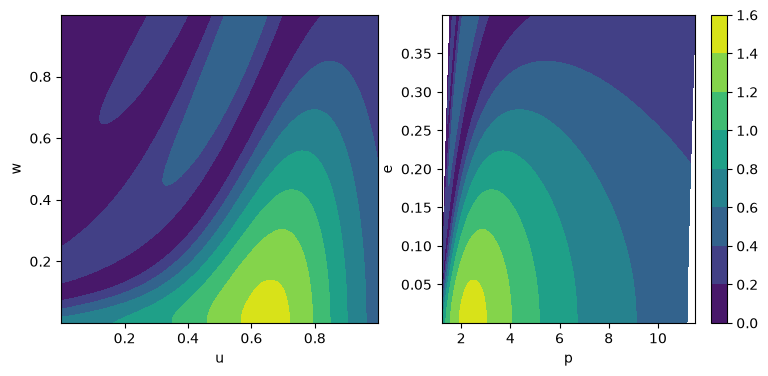

In [10]:
# Look at the contours of the (2,2,0,0) mode using teuk_all_amps
plt.figure(figsize=(9, 4))
plt.subplot(121)
cb = plt.contourf(
    u_grid.reshape(uv.size, wv.size),
    w_grid.reshape(uv.size, wv.size),
    np.abs(teuk_all_amps_nex[:, :, kerr_amp_spline_nex.special_index_map[(2,2, 0, 0)]]),
)
plt.xlabel("u")
plt.ylabel("w")
plt.subplot(122)
cb = plt.contourf(
    p_grid_nex.reshape(uv.size, wv.size),
    e_grid_nex.reshape(uv.size, wv.size),
    np.abs(teuk_all_amps_nex[:, :, kerr_amp_spline_nex.special_index_map[(2,2, 0, 0)]]),
)
plt.colorbar(cb)
plt.xlabel("p")
plt.ylabel("e")
plt.show()